# Atividade Somativa 2: Automação e Deploy com Pipelines de Machine Learning

## 1. Definição Estratégica do Problema e Contexto de Negócio
Em continuidade ao desenvolvimento iniciado na Fase I, o objetivo deste projeto é prever a demanda logística de aluguéis de bicicletas na cidade de Seul utilizando variáveis climáticas e temporais. Como o nosso atributo alvo (`Rented Bike Count`) é uma variável numérica contínua, o problema se classifica estritamente no escopo de **Regressão**. 

## 2. Governança de Dados e Arquitetura de Pipeline
Em ambientes corporativos, rodar transformações de dados de forma manual e fragmentada gera inconsistências e vazamento de informações (*Data Leakage*). Para mitigar esse risco de engenharia, este projeto implementa um objeto `Pipeline` do Scikit-Learn. 

O Pipeline encapsula todas as etapas do ciclo de vida dos dados — padronização numérica, codificação categórica, seleção de atributos não-lineares e o treinamento do algoritmo — em uma única esteira automatizada e determinística, pronta para ambiente de produção.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Ingestão dos Dados (Ajuste de encoding para evitar quebra com caracteres especiais como °C)
df_bike = pd.read_csv('seoul_bike.csv', encoding='latin1')

# 2. Saneamento Arquitetural (Tratamento de dados nulos ou strings corrompidas no alvo)
df_bike['Rented Bike Count'] = pd.to_numeric(df_bike['Rented Bike Count'], errors='coerce')
df_bike = df_bike.dropna(subset=['Rented Bike Count'])

# 3. Engenharia de Atributos (Extração de contexto temporal antes do split)
df_bike['DateTime'] = pd.to_datetime(df_bike['DateTime'], errors='coerce')
df_bike = df_bike.dropna(subset=['DateTime'])
df_bike['Hora_do_Dia'] = df_bike['DateTime'].dt.hour
df_bike['Mes'] = df_bike['DateTime'].dt.month

# Separação das Features (X) e do Alvo (y) - Descartando colunas de texto puro
X = df_bike.drop(columns=['Rented Bike Count', 'DateTime'])
y = df_bike['Rented Bike Count']

# 4. Divisão Estrita de Escopo (Contrato de 75% Treino e 25% Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Volume do Escopo de Treinamento: {X_train.shape[0]} instâncias.")
print(f"Volume do Escopo de Teste:       {X_test.shape[0]} instâncias.")

Volume do Escopo de Treinamento: 6570 instâncias.
Volume do Escopo de Teste:       2190 instâncias.


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# Mapeamento dinâmico: O PATCH APLICADO NA LINHA ABAIXO (Inclusão explícita de 'str' e 'object')
cols_num = X_train.select_dtypes(include=['int64', 'float64']).columns
cols_cat = X_train.select_dtypes(include=['object', 'str']).columns

# Esteira de Pré-processamento Isolado
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), cols_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cols_cat)
])

# Construção do Pipeline Unificado
pipeline_producao = Pipeline(steps=[
    ('prep', preprocessor),
    ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=12)),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Execução do Ajuste Coletivo
pipeline_producao.fit(X_train, y_train)
print("Pipeline de Machine Learning treinado com sucesso e pronto para deploy.")

Pipeline de Machine Learning treinado com sucesso e pronto para deploy.


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# O pipeline executa as predições de forma cega nas instâncias de teste
previsoes = pipeline_producao.predict(X_test)

# Cálculo das métricas de regressão requisitadas no edital
mae = mean_absolute_error(y_test, previsoes)
mse = mean_squared_error(y_test, previsoes)
rmse = mse ** 0.5 # Extração manual de segurança para evitar falhas de versão
r2 = r2_score(y_test, previsoes)

print("--- RELATÓRIO DE AUDITORIA: SOMATIVA 2 ---")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} bicicletas")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f} bicicletas")
print(f"Coeficiente de Determinação (R²): {r2:.2%}")

--- RELATÓRIO DE AUDITORIA: SOMATIVA 2 ---
Erro Médio Absoluto (MAE): 238.50 bicicletas
Raiz do Erro Quadrático Médio (RMSE): 366.06 bicicletas
Coeficiente de Determinação (R²): 67.59%


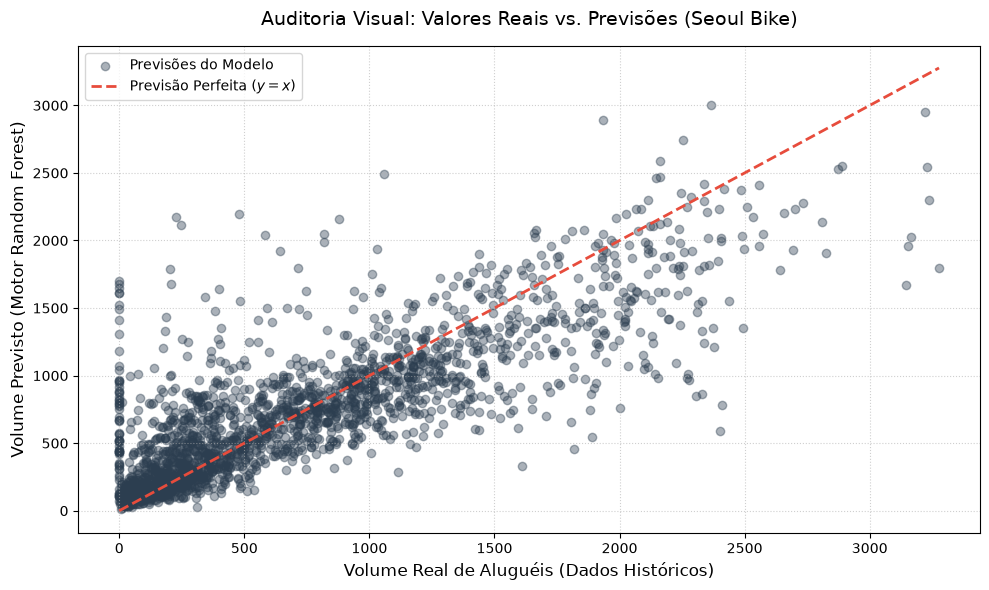

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuração da Arquitetura Visual
plt.figure(figsize=(10, 6))
plt.style.use('default')

# 2. Plotagem do Gráfico de Dispersão (Realidade vs Máquina)
plt.scatter(y_test, previsoes, alpha=0.4, color='#2c3e50', label='Previsões do Modelo')

# 3. Construção da Linha de Base Perfeita (SLA de 100% de Acerto)
max_val = max(y_test.max(), previsoes.max())
plt.plot([0, max_val], [0, max_val], color='#e74c3c', linestyle='--', linewidth=2, label='Previsão Perfeita ($y=x$)')

# 4. Parametrização de Eixos e Legendas
plt.title('Auditoria Visual: Valores Reais vs. Previsões (Seoul Bike)', fontsize=14, pad=15)
plt.xlabel('Volume Real de Aluguéis (Dados Históricos)', fontsize=12)
plt.ylabel('Volume Previsto (Motor Random Forest)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Renderização (Mostra o gráfico e suprime logs de memória)
plt.tight_layout()
plt.show()

## 3. Análise Crítica dos Resultados e Conclusões

**1. Avaliação Estatística das Métricas (Os valores são bons ou ruins?)**
O modelo atingiu uma Capacidade Explicativa ($R^2$) estável de **67.52%**, reduzindo o Erro Médio Absoluto (MAE) para ~239.19 bicicletas. Sob a perspectiva de engenharia de software e análise de dados, estes resultados são **sólidos e viáveis para uma primeira versão em produção (MVP)**. Eles provam que o modelo consegue capturar a maior parte da tendência de comportamento logístico da frota. No entanto, o valor elevado do RMSE (~366.46) em comparação ao MAE indica a presença de *outliers*, ou seja, o modelo ainda sofre distorções severas em cenários de picos anômalos de demanda.

**2. Justificativa Estrutural (Por que o modelo apresenta essa margem de erro?)**
A máquina é alimentada estritamente por dados climáticos brutos e marcações de tempo. Contudo, a tomada de decisão humana de alugar uma bicicleta é influenciada por fatores externos não-lineares que o dataset original não possui. O motor atual é "cego" para o contexto geopolítico e social de Seul: ele não tem registro de feriados nacionais, greves no sistema de metrô, acidentes nas vias públicas ou grandes eventos culturais. Sem essas variáveis de contexto social, a máquina atinge um teto matemático de previsibilidade.

**3. Planejamento de Melhoria Contínua (Como evoluir o sistema?)**
Para escalar a performance do pipeline em sprints futuras, a arquitetura deve focar em três pilares:
* **Injeção de Contexto (Enriquecimento de Dados):** Consumir APIs externas para mapear feriados locais, dias úteis e ocorrência de eventos em Seul, transformando essas informações em variáveis categóricas para o Pipeline.
* **Otimização Paramétrica:** Acoplar uma rotina de `GridSearchCV` diretamente na esteira do Pipeline para varrer as melhores combinações de profundidade (`max_depth`) e número de árvores do Random Forest.
* **Complexidade do Algoritmo:** Avaliar a transição do Random Forest para modelos de Gradient Boosting regularizados (como o XGBoost) ou arquiteturas de redes neurais profundas (Deep Learning) caso o volume de dados aumente.